# **10. Modelo original**


## **Contexto del problema y naturaleza del dataset**

El dataset Heart 2022 contiene 246.022 registros y 40 variables. La variable objetivo es:

HadDiabetes (0 = no, 1 = sí)

Distribución observada:

- Clase 0 (No diabetes): ~212.202 casos  
- Clase 1 (Con diabetes): ~33.811 casos  

La clase positiva solo representa ~13.7%.

### **Problema central**
Los modelos tradicionales:

- predicen casi siempre la clase 0,
- muestran accuracy alto pero recall muy bajo para la clase 1,
- no detectan adecuadamente casos de diabetes.

Como en salud pública es más grave perder un caso positivo que generar un falso positivo, el objetivo del proyecto es maximizar la sensibilidad (recall) de la clase 1.



## **Limitaciones de los modelos existentes**

Se probaron modelos como:

- Regresión Logística  
- Random Forest estándar  
- Gradient Boosting estándar  
- Modelos con class_weight  
- Técnicas como SMOTENC  

Incluso así, el comportamiento fue:

- Bajo recall de la clase minoritaria  
- Predicciones dominadas por la clase 0  
- Incapacidad para modelar relaciones complejas entre variables clínicas, demográficas y de estilo de vida

También se intentó implementar el algoritmo CMBoost (Zhang, 2019), que teóricamente es ideal para datos desbalanceados.  
Sin embargo, CMBoost requiere construir matrices cuadradas del tamaño:

N x N, donde N = número de registros (en este caso 246.022)

Esto implica más de 600 GB de memoria, lo cual es inviable.



## **Por qué surge la necesidad de un modelo híbrido**

Se necesitaba un modelo que:

1. Mantuviera la filosofía cost-sensitive de CMBoost.  
2. Fuera escalable y no dependiera de matrices gigantes.  
3. Funcionara con 246k muestras.  
4. Maximizara el recall de la clase minoritaria.  
5. Capturara relaciones no lineales y múltiples interacciones entre variables de salud.

Dado que ningún modelo estándar cumplía con todo, se construyó un modelo nuevo:  
**El Modelo Híbrido Cost-Sensitive.**



## **Ideas teóricas que inspiran el modelo**

### **Aporte tomado de CMBoost (Zhang, 2019)**
CMBoost introduce dos conceptos principales:

- usar pesos mayores para la clase minoritaria,
- aumentar el margen medio y disminuir la varianza del margen para mejorar la generalización.

Como no podemos calcular los márgenes globales por el tamaño del dataset, se toma la idea esencial:

“Los ejemplos de la clase minoritaria deben tener un peso mayor en la función de pérdida.”

Esto se implementa con un Gradient Boosting cost-sensitive usando sample_weight.



### **Aporte tomado de Pes & Lai (2021)**
Este paper muestra que se puede imitar el comportamiento de modelos cost-sensitive complejos utilizando:

- sample weighting,
- penalizaciones proporcionales al desbalance,
- ajustes directos en la función de pérdida.

Esto permite adoptar la esencia teórica de CMBoost pero manteniendo una implementación eficiente.



### **Aporte tomado de Kadkhodaei et al. (2021)**

Este trabajo demuestra que:

- combinar modelos diferentes,
- con distintos sesgos inductivos,
- mejora el rendimiento en Big Data,
- y especialmente en datasets desbalanceados.

Por eso se incorpora un segundo bloque: Balanced Random Forest.

Este modelo:

- hace bootstrap balanceado dentro del árbol,
- maneja naturalmente variables categóricas,
- aporta robustez y estabilidad.



## **Cómo está construido el modelo híbrido**

El modelo final combina dos módulos:

### **Gradient Boosting Cost-Sensitive**
- Utiliza sample_weight para penalizar más los errores en la clase 1.  
- Optimiza una pérdida donde los casos positivos tienen mayor impacto.  
- Captura patrones suaves, continuos y no lineales.

### **Balanced Random Forest**
- Re-muestrea internamente para tener igual cantidad de positivos y negativos en cada árbol.  
- Captura relaciones fuertes, abruptas y basadas en interacciones entre variables.

### **Fusión probabilística (innovación propia del modelo)**
Las probabilidades de ambos modelos se combinan:

prob_final = (prob_GB + prob_RF) / 2

Esto aporta:

- estabilidad,
- reducción de sesgo hacia la clase mayoritaria,
- mejor sensibilidad,
- y aprovechamiento simultáneo de dos enfoques diferentes.

Esta capa final **no existe en CMBoost, ni en los otros papers, ni en sklearn**.  
Es el componente completamente original del modelo.



## **Por qué este modelo resuelve el problema del dataset**

1. Maneja el desbalance desde dos frentes:  
   - cost-sensitive boosting,  
   - bootstrap balanceado en Random Forest.

2. Captura relaciones complejas entre 40 variables variadas.  

3. Es escalable:  
   - no usa matrices cuadradas,  
   - no genera MemoryError,  
   - se puede entrenar con 246k registros.

4. Maximiza el recall de la clase con diabetes, que es el objetivo fundamental.

5. Equilibra precisión y sensibilidad mediante la capa de fusión.

6. Nace directamente de las necesidades del proyecto y de las limitaciones reales encontradas en la práctica.



## **Por qué este modelo es original**

- No existe en sklearn ni en imbalanced-learn.  
- No es CMBoost, pero está inspirado en su marco teórico.  
- No es ningún modelo de los papers revisados, pero combina ideas de los tres.  
- Es una arquitectura híbrida diseñada específicamente para datos de salud desbalanceados.  
- Su capa de fusión probabilística es una contribución original.  

El modelo surge como una solución práctica, teóricamente fundamentada y computacionalmente viable para el dataset de 2022.



## **Implementación**

Se importan las librerías.

In [1]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.tree import DecisionTreeClassifier
import cvxpy as cp
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import classification_report
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, recall_score


Se importan las bases necesarias.

In [2]:
X = pd.read_csv('df_limpio.csv').drop(columns=["diabetes"])

In [3]:
y = pd.read_csv('df_limpio.csv')["diabetes"]

In [4]:
X_train_ = pd.read_csv('X_train.csv')
X_test_ = pd.read_csv('X_test.csv')
y_train_ = pd.read_csv('y_train.csv')["diabetes"]
y_test_ = pd.read_csv('y_test.csv')["diabetes"]

## **CMBoost Classifier**

El algoritmo **CMBoost** (Zhang, 2019) propone una optimización del margen ponderado por costo para abordar problemas de clasificación desbalanceada. Sin embargo, su implementación exacta requiere manipular una matriz \(N \times N\), lo cual implica:

- complejidad espacial \(O(N^2)\),
- complejidad temporal elevada,
- consumo de memoria que crece cuadráticamente.

En el dataset utilizado en este proyecto (≈ 300k observaciones), la implementación exacta genera errores del tipo:

``MemoryError: Unable to allocate >600 GiB``

Por tanto, se vuelve **inviable** aplicar CMBoost exactamente sobre el conjunto completo.

In [5]:
class CMBoostClassifier(BaseEstimator, ClassifierMixin):
    """
    Implementación del algoritmo CMBoost de Zhang (2019).

    - f(x) = sum_j alpha_j h_j(x)
    - y en {-1, +1}
    - h_j(x) en {-1, +1}
    - Problema principal (ec. 28):
        min_{alpha, rho}  1/2 rho^T B rho + lambda_g^T rho
        s.t. alpha >= 0, 1^T alpha = D
             rho_i = y_i h_i^T alpha

    Parámetros
    ----------
    base_estimator : clf sklearn, opcional
        Clasificador débil. Por defecto: árbol de decisión profundidad 1.
    n_estimators : int
        Número máximo de iteraciones (column generation / boosting rounds).
    lambda1 : float
        λ1 en el paper.
    lambda2 : float
        λ2 en el paper.
    c_cost : float
        Parámetro de costo c de las ec. (18)–(19).
    D : float
        Constante D de la restricción 1^T alpha = D (en el paper es una constante positiva).
    solver : str
        Solver de cvxpy ('SCS', 'OSQP', 'ECOS', etc.)
    verbose : bool
        Si True, imprime info de cada iteración.
    """

    def __init__(self,
                 base_estimator=None,
                 n_estimators=10,
                 lambda1=1.0,
                 lambda2=1.0,
                 c_cost=1.0,
                 D=1.0,
                 solver="SCS",
                 verbose=False):

        if base_estimator is None:
            base_estimator = DecisionTreeClassifier(max_depth=1)

        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.lambda1 = float(lambda1)
        self.lambda2 = float(lambda2)
        self.c_cost = float(c_cost)
        self.D = float(D)
        self.solver = solver
        self.verbose = verbose

    # ---------- Utilidades internas ----------

    def _encode_labels(self, y):
        """
        Mapea etiquetas originales a {-1, +1}
        y guarda la info para deshacer el mapeo en predict().
        """
        y = np.asarray(y)
        classes = np.unique(y)
        if classes.size != 2:
            raise ValueError("CMBoost solo soporta clasificación binaria.")

        # Tomamos classes[0] = -1, classes[1] = +1
        self.classes_ = classes
        y_signed = np.where(y == classes[1], 1.0, -1.0)
        return y_signed

    def _build_cost_sensitive_matrices(self, y_signed):
        """
        Construye A, d_i, k_i, K, B, lambda_g siguiendo
        las ecuaciones (11), (18)-(19), (23)-(26) del paper.
        """
        y_signed = np.asarray(y_signed).astype(float)
        N = y_signed.shape[0]

        # --- (11) Matriz A ---
        c_A = -1.0 / (N - 1.0)
        A = np.full((N, N), c_A, dtype=float)
        np.fill_diagonal(A, 1.0)

        # --- desequilibrio ru = n_- / n_+ ---
        idx_pos = np.where(y_signed == 1.0)[0]
        idx_neg = np.where(y_signed == -1.0)[0]
        n_plus = idx_pos.size
        n_minus = idx_neg.size

        if n_plus == 0 or n_minus == 0:
            raise ValueError("Todas las etiquetas son iguales; CMBoost necesita clases  +1  y  -1.")

        r_u = n_minus / n_plus
        c = self.c_cost

        # --- (18) pesos d_i ---
        d = np.empty(N, dtype=float)
        term_pos = 1.0 + c * r_u * abs(np.log(r_u))
        term_neg = 1.0 + c * (1.0 / r_u) * abs(np.log(1.0 / r_u))

        d[idx_pos] = term_pos
        d[idx_neg] = term_neg

        # --- (19) pesos k_i ---
        k = np.empty(N, dtype=float)
        k[idx_pos] = term_neg      # fíjate en el cambio cruzado
        k[idx_neg] = term_pos

        # --- (23) K = diag(k1,...,kN) ---
        K = np.diag(k)

        # --- (24) B = K^T A K (como K es diagonal, K^T = K) ---
        B = K @ A @ K

        # --- (25) vector d (ya lo tenemos) ---
        # d = [d1,...,dN]

        # --- (26) lambda_g = - lambda2 / (2 N lambda1) * d ---
        lambda_g = - self.lambda2 / (2.0 * N * self.lambda1) * d

        return B, lambda_g, d, k, r_u

    def _compute_H_column(self, estimator, X):
        """
        Devuelve h(x_i) en {-1, +1} para todos los i.

        Si el estimador predice 0/1, lo mapeamos a -1/+1.
        """
        X = np.asarray(X)
        # Intentamos usar predict_proba si existe
        if hasattr(estimator, "predict_proba"):
            proba = estimator.predict_proba(X)[:, 1]
            h = np.where(proba >= 0.5, 1.0, -1.0)
        else:
            pred = estimator.predict(X)
            # Mapear a -1/+1 usando las clases originales
            h = np.where(pred == self.classes_[1], 1.0, -1.0)

        return h.astype(float)

    # ---------- API principal ----------

    def fit(self, X, y):
        """
        Entrena CMBoost sobre (X, y).
        """
        X = np.asarray(X)
        y_signed = self._encode_labels(y)
        N = X.shape[0]

        # Construir matrices costo-sensibles
        B, lambda_g, d_vec, k_vec, r_u = self._build_cost_sensitive_matrices(y_signed)
        self.B_ = B
        self.lambda_g_ = lambda_g
        self.d_vec_ = d_vec
        self.k_vec_ = k_vec
        self.r_u_ = r_u

        # Lista de clasificadores débiles
        self.estimators_ = []
        H_cols = []

        # Inicializar "u" (dual) con algo razonable: uniforme
        u = np.ones(N) / N

        for t in range(self.n_estimators):
            if self.verbose:
                print(f"\n=== Iteración {t+1}/{self.n_estimators} ===")

            # 1) Entrenamos un nuevo clasificador base usando pesos ~ |u_i|
            base = clone(self.base_estimator)
            sample_weight = np.abs(u)
            if sample_weight.sum() == 0:
                sample_weight = None

            # Para el estimador base, usamos y en {0,1}
            y_binary = (y_signed == 1.0).astype(int)
            base.fit(X, y_binary, sample_weight=sample_weight)
            self.estimators_.append(base)

            # 2) Calculamos su columna h(x_i)
            h_col = self._compute_H_column(base, X)  # N vector en {-1,+1}
            H_cols.append(h_col)

            # Matriz H (N x M)
            H = np.column_stack(H_cols)
            M = H.shape[1]

            # 3) Definimos variables del QP (28)
            alpha = cp.Variable(M)
            rho = cp.Variable(N)

            # Objetivo: 1/2 rho^T B rho + lambda_g^T rho
            objective = 0.5 * cp.quad_form(rho, B) + lambda_g @ rho

            # Restricciones:
            # - alpha >= 0
            # - 1^T alpha = D
            # - rho = y .* (H alpha)
            constraints = [
                alpha >= 0,
                cp.sum(alpha) == self.D,
                rho == cp.multiply(y_signed, H @ alpha)
            ]

            prob = cp.Problem(cp.Minimize(objective), constraints)
            prob.solve(solver=self.solver, verbose=False)

            if prob.status not in ["optimal", "optimal_inaccurate"]:
                raise RuntimeError(f"El QP no convergió (status: {prob.status})")

            alpha_val = np.array(alpha.value).reshape(-1)
            rho_val = np.array(rho.value).reshape(-1)

            self.alpha_ = alpha_val
            self.rho_ = rho_val
            self.H_ = H

            # 4) Recuperamos el dual de la restricción rho == y .* (H alpha)
            #    Esto corresponde al vector u del paper.
            u = constraints[2].dual_value.reshape(-1)

            if self.verbose:
                obj_val = objective.value
                margin_mean = (rho_val).mean()
                print(f"   Objetivo QP (28): {obj_val:.6f}")
                print(f"   ||alpha||_1 = {alpha_val.sum():.6f}")
                print(f"   Media de márgenes (aprox): {margin_mean:.6f}")

        return self

    def _decision_function(self, X):
        """
        f(x) = sum_j alpha_j h_j(x)
        """
        X = np.asarray(X)
        if not hasattr(self, "alpha_"):
            raise RuntimeError("Debes entrenar el modelo con fit() primero.")

        H_new = []
        for est in self.estimators_:
            h_col = self._compute_H_column(est, X)
            H_new.append(h_col)
        H_new = np.column_stack(H_new)  # (n_samples, M)

        f = H_new @ self.alpha_
        return f

    def predict(self, X):
        """
        Predicción de etiquetas originales (las mismas que en y de fit).
        """
        f = self._decision_function(X)
        y_signed_pred = np.where(f >= 0, 1.0, -1.0)
        # Deshacer el mapeo
        y_pred = np.where(y_signed_pred == 1.0,
                          self.classes_[1],
                          self.classes_[0])
        return y_pred

    def predict_proba(self, X):
        """
        Probabilidades aproximadas usando función sigmoide sobre f(x).
        """
        f = self._decision_function(X)
        # Sigmoide
        p_pos = 1.0 / (1.0 + np.exp(-f))
        p_neg = 1.0 - p_pos
        return np.vstack([p_neg, p_pos]).T


In [7]:

numeric_features = X_train_.select_dtypes(include="number").columns
categorical_features = X_train_.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    # ('balanceo', smote),  # <-- solo si lo necesitas
    ('model', CMBoostClassifier(
    n_estimators=10,    # empieza con algo pequeño
    lambda1=1.0,
    lambda2=1.0,
    c_cost=1.0,
    D=1.0,
    solver="SCS",
    verbose=True       # pon False si no quieres logs
    ))
])

### **Toma de Submuestra**

El algoritmo CMBoost no puede aplicarse al dataset completo porque requiere construir matrices internas de tamaño N x N. Con 246.000 registros, esto supera ampliamente la memoria disponible (más de 600 GB), haciendo imposible su ejecución total.

Para poder evaluar su comportamiento y rescatar sus ideas principales, se toma una submuestra del dataset. Esta submuestra permite:

- Probar el funcionamiento del algoritmo en un entorno controlado.  
- Analizar si realmente mejora la detección de la clase minoritaria.  
- Revisar cómo se comporta frente a modelos tradicionales.  

El objetivo de esta submuestra no es entrenar el modelo final, sino entender qué elementos teóricos de CMBoost pueden incorporarse posteriormente al Modelo Híbrido Cost-Sensitive, que sí es escalable al dataset completo.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Suponiendo que ya tienes X y y (pandas o numpy)
X_arr = np.asarray(X)
y_arr = np.asarray(y)

# Etiqueta positiva (ajusta si tu positiva NO es 1)

pos_label = 1

pos_idx = np.where(y == pos_label)[0]
neg_idx = np.where(y != pos_label)[0]

max_total = 5000
max_pos = min(len(pos_idx), int(max_total * 0.6))
max_neg = max_total - max_pos

rng = np.random.RandomState(42)
pos_sample = rng.choice(pos_idx, size=max_pos, replace=False)
neg_sample = rng.choice(neg_idx, size=max_neg, replace=False)

sub_idx = np.concatenate([pos_sample, neg_sample])
rng.shuffle(sub_idx)

# IMPORTANTÍSIMO: usamos iloc para mantener DataFrame/Serie
X_sub = X.iloc[sub_idx].copy()
y_sub = y.iloc[sub_idx].copy()

print(X_sub.shape)
print(y_sub.value_counts())



(5000, 39)
diabetes
1    3000
0    2000
Name: count, dtype: int64


En esta submuestra se cuenta con un total de 5.000 observaciones y 39 variables predictoras. La variable objetivo `diabetes` presenta la siguiente distribución de clases:

- Clase 1 (con diabetes): 3.000 registros  
- Clase 0 (sin diabetes): 2.000 registros  

Esto significa que, a diferencia del dataset completo, la submuestra está moderadamente balanceada a favor de la clase positiva. Esta configuración es útil para probar el CMBoost y otros modelos cost-sensitive en un entorno donde la clase minoritaria del problema original (personas con diabetes) está mejor representada, facilitando la evaluación de su capacidad de detección.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.3,
    stratify=y_sub,
    random_state=42
)

print("Tamaño train:", X_train.shape[0])
print("Tamaño test :", X_test.shape[0])


Tamaño train: 3500
Tamaño test : 1500


La submuestra se dividió en dos conjuntos:

- **Train:** 3.500 observaciones  
- **Test:** 1.500 observaciones  

Esta partición permite entrenar los modelos en un conjunto suficientemente amplio para aprender los patrones principales, mientras que el conjunto de prueba mantiene una proporción adecuada para evaluar el desempeño general y la capacidad de generalización del modelo.

In [10]:
import numpy as np
unique, counts = np.unique(y, return_counts=True)
dict(zip(unique, counts))


{np.int64(0): np.int64(212202), np.int64(1): np.int64(33811)}

En el dataset completo se observa un fuerte desbalance en la variable objetivo:

- Clase 0 (sin diabetes): 212.202 registros  
- Clase 1 (con diabetes): 33.811 registros  

Esto significa que la clase positiva representa aproximadamente solo el 13.7% del total.  
Este desbalance severo es uno de los principales desafíos del problema, ya que los modelos tradicionales tienden a favorecer la clase mayoritaria y fallan en detectar casos positivos, lo que afecta directamente el objetivo de maximizar el recall en la predicción de diabetes.

In [11]:
unique, counts = np.unique(y_train, return_counts=True)
dict(zip(unique, counts))


{np.int64(0): np.int64(1400), np.int64(1): np.int64(2100)}

En la submuestra utilizada para probar CMBoost y otros métodos, la distribución de clases es la siguiente:

- Clase 0 (sin diabetes): 1.400 registros  
- Clase 1 (con diabetes): 2.100 registros  

A diferencia del dataset completo, esta submuestra presenta un desbalance moderado a favor de la clase positiva. Esto facilita la evaluación de modelos cost-sensitive y permite analizar su comportamiento sin las limitaciones extremas del desbalance original.


In [12]:
pipeline.fit(X_train, y_train)


=== Iteración 1/10 ===
   Objetivo QP (28): 3247.521472
   ||alpha||_1 = 1.000000
   Media de márgenes (aprox): 0.312000

=== Iteración 2/10 ===
   Objetivo QP (28): 2105.332181
   ||alpha||_1 = 1.000000
   Media de márgenes (aprox): 0.286969

=== Iteración 3/10 ===
   Objetivo QP (28): 1552.677865
   ||alpha||_1 = 1.000000
   Media de márgenes (aprox): 0.285183

=== Iteración 4/10 ===
   Objetivo QP (28): 1497.962481
   ||alpha||_1 = 1.000000
   Media de márgenes (aprox): 0.286801

=== Iteración 5/10 ===
   Objetivo QP (28): 1497.962179
   ||alpha||_1 = 1.000000
   Media de márgenes (aprox): 0.286801

=== Iteración 6/10 ===
   Objetivo QP (28): 1497.960032
   ||alpha||_1 = 0.999999
   Media de márgenes (aprox): 0.286801

=== Iteración 7/10 ===
   Objetivo QP (28): 1497.984382
   ||alpha||_1 = 1.000007
   Media de márgenes (aprox): 0.286803

=== Iteración 8/10 ===
   Objetivo QP (28): 1497.962447
   ||alpha||_1 = 1.000000
   Media de márgenes (aprox): 0.286801

=== Iteración 9/10 ===


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
y_pred = pipeline.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

[[244 356]
 [109 791]]
              precision    recall  f1-score   support

           0     0.6912    0.4067    0.5121       600
           1     0.6896    0.8789    0.7728       900

    accuracy                         0.6900      1500
   macro avg     0.6904    0.6428    0.6425      1500
weighted avg     0.6903    0.6900    0.6685      1500



En la submuestra de prueba (1.500 registros), el modelo obtuvo una accuracy global de 0.69, con un desempeño claramente orientado a la detección de la clase positiva. La matriz de confusión muestra que se identificaron correctamente 791 de los 900 casos de diabetes (clase 1), lo que se refleja en un recall muy alto de 0.8789 y un F1-score de 0.7728 para esta clase, a costa de una menor sensibilidad en la clase 0 (recall de 0.4067 y F1-score de 0.5121). En conjunto, estos resultados indican que el modelo aplicado sobre la submuestra cumple el objetivo de priorizar la identificación de personas con diabetes, aun sacrificando parte del rendimiento en la clase negativa, lo cual es coherente con la naturaleza del problema y la importancia de minimizar falsos negativos en un contexto de salud.


## **Aplicacion por separado de Modelos complementarios**

In [14]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# 1) Pesos de clase automáticos (tipo cost-sensitive)
classes = np.unique(y_train_)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_
)
w_dict = {cls: w for cls, w in zip(classes, class_weights)}
print("Pesos por clase:", w_dict)

# Vector de pesos para cada muestra del train
sample_weight = np.array([w_dict[label] for label in y_train_])

# 2) Modelo Gradient Boosting (más estable que nuestro boost casero)
gb_cs = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# 3) Pipeline completo con tu preprocesador
pipeline_gb = Pipeline(steps=[
    ("prep", preprocessor),   # tu ColumnTransformer(num, cat)
    ("model", gb_cs)
])

# 4) Entrenar con pesos
pipeline_gb.fit(X_train_, y_train_, model__sample_weight=sample_weight)

# 5) Evaluar
y_pred = pipeline_gb.predict(X_test_)
print("MATRIZ DE CONFUSIÓN - GradientBoosting cost-sensitive")
print(confusion_matrix(y_test_, y_pred))
print(classification_report(y_test_, y_pred, digits=4))


Pesos por clase: {np.int64(0): np.float64(0.5796682397452555), np.int64(1): np.float64(3.638013351360487)}
MATRIZ DE CONFUSIÓN - GradientBoosting cost-sensitive
[[45260 18401]
 [ 2260  7883]]
              precision    recall  f1-score   support

           0     0.9524    0.7110    0.8142     63661
           1     0.2999    0.7772    0.4328     10143

    accuracy                         0.7201     73804
   macro avg     0.6262    0.7441    0.6235     73804
weighted avg     0.8628    0.7201    0.7618     73804



El modelo Gradient Boosting cost-sensitive, entrenado con pesos calculados por clase ({0: 0.5797, 1: 3.6380}), muestra un rendimiento claramente orientado a mejorar la detección de la clase minoritaria. En el conjunto completo de prueba (73.804 registros), la matriz de confusión refleja que el modelo identifica correctamente 7.883 de los 10.143 casos positivos, logrando un recall de 0.7772 para la clase 1, muy superior al que ofrecen modelos tradicionales sin ajuste de costos. Aunque la precisión de esta clase es baja (0.2999), el comportamiento es coherente con la estrategia cost-sensitive: se privilegia reducir los falsos negativos (es decir, no dejar pasar casos reales de diabetes) aun a costa de aumentar falsos positivos. Para la clase 0, el modelo mantiene buena precisión (0.9524), pero su recall desciende a 0.7110 debido al énfasis en detectar la clase minoritaria. En conjunto, los resultados muestran que el Gradient Boosting ponderado cumple su propósito: mejorar significativamente la identificación de personas con diabetes en un dataset altamente desbalanceado, logrando un balance adecuado entre sensibilidad y rendimiento general.


In [16]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

brf = BalancedRandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

pipeline_brf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", brf)
])

pipeline_brf.fit(X_train_, y_train_)

y_pred_brf = pipeline_brf.predict(X_test_)
print("MATRIZ DE CONFUSIÓN - BalancedRandomForest")
print(confusion_matrix(y_test_, y_pred_brf))
print(classification_report(y_test_, y_pred_brf, digits=4))


MATRIZ DE CONFUSIÓN - BalancedRandomForest
[[47141 16520]
 [ 2667  7476]]
              precision    recall  f1-score   support

           0     0.9465    0.7405    0.8309     63661
           1     0.3116    0.7371    0.4380     10143

    accuracy                         0.7400     73804
   macro avg     0.6290    0.7388    0.6344     73804
weighted avg     0.8592    0.7400    0.7769     73804



El modelo Balanced Random Forest muestra un desempeño sólido en el dataset completo, con una accuracy global de 0.74 y un comportamiento equilibrado entre ambas clases dentro de un contexto de desbalance severo. La matriz de confusión indica que se identifican correctamente 7.476 de los 10.143 casos de diabetes (clase 1), alcanzando un recall de 0.7371 y un F1-score de 0.4380 para esta clase, lo que confirma su capacidad para recuperar una proporción importante de positivos. Al mismo tiempo, la clase 0 mantiene una precisión alta (0.9465) y un recall de 0.7405, con un F1-score de 0.8309, lo que refleja que el modelo sigue siendo fuerte en la clase mayoritaria. En conjunto, estos resultados muestran que Balanced Random Forest es especialmente útil para manejar el desbalance del problema, ya que logra una buena sensibilidad para la clase con diabetes sin deteriorar de forma extrema el rendimiento en la clase negativa, mejorando así el equilibrio entre detección de casos positivos y estabilidad general del modelo.


## **Modelo Original `HybridCostSensitiveEnsemble`**

El modelo original `HybridCostSensitiveEnsemble` combina dos enfoques complementarios para manejar el fuerte desbalance del dataset: un Gradient Boosting cost-sensitive, que asigna mayor peso a los casos positivos para mejorar su detección, y un Balanced Random Forest, que utiliza muestreo balanceado en cada árbol para reducir el sesgo hacia la clase mayoritaria. Las probabilidades de ambos modelos se fusionan mediante un promedio simple, creando un ensamble híbrido capaz de incrementar significativamente el recall de la clase minoritaria sin perder estabilidad en la clase mayoritaria.


In [17]:
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    HAS_IMB = True
except ImportError:
    HAS_IMB = False


class HybridCostSensitiveEnsemble(BaseEstimator, ClassifierMixin):
    """
    Modelo híbrido cost-sensitive y escalable.

    Combina:
      - GradientBoostingClassifier con sample_weight (cost-sensitive)
      - BalancedRandomForestClassifier (o RandomForest con class_weight="balanced_subsample")

    En predicción:
      p_hibrido = (p_gb + p_rf) / 2

    Parámetros
    ----------
    gb_params : dict
        Hiperparámetros para GradientBoostingClassifier.
    rf_params : dict
        Hiperparámetros para (Balanced)RandomForest.
    use_balanced_rf : bool
        Si True y está imbalanced-learn instalado, usa BalancedRandomForestClassifier.
    """

    def __init__(self,
                 gb_params=None,
                 rf_params=None,
                 use_balanced_rf=True,
                 random_state=None):

        self.gb_params = gb_params
        self.rf_params = rf_params
        self.use_balanced_rf = use_balanced_rf
        self.random_state = random_state

    def _init_models(self):
        gb_defaults = dict(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=self.random_state
        )
        if self.gb_params is not None:
            gb_defaults.update(self.gb_params)
        self.gb_ = GradientBoostingClassifier(**gb_defaults)

        if self.use_balanced_rf and HAS_IMB:
            rf_cls = BalancedRandomForestClassifier
            rf_defaults = dict(
                n_estimators=300,
                max_depth=None,
                min_samples_split=10,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=self.random_state
            )
        else:
            rf_cls = RandomForestClassifier
            rf_defaults = dict(
                n_estimators=300,
                max_depth=None,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=self.random_state
            )

        if self.rf_params is not None:
            rf_defaults.update(self.rf_params)
        self.rf_ = rf_cls(**rf_defaults)

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)

        # Inicializamos modelos
        self._init_models()

        # Pesos de clase para cost-sensitive (como d_i agregados por clase)
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=self.classes_,
            y=y
        )
        w_dict = {cls: w for cls, w in zip(self.classes_, class_weights)}
        sample_weight = np.array([w_dict[label] for label in y])

        # Entrenamos GB con sample_weight
        self.gb_.fit(X, y, sample_weight=sample_weight)

        # Entrenamos RF (BalancedRF ya maneja el desbalance internamente)
        self.rf_.fit(X, y)

        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["gb_", "rf_", "classes_"])
        X = check_array(X)

        proba_gb = self.gb_.predict_proba(X)
        proba_rf = self.rf_.predict_proba(X)

        # promedio simple (podrías cambiar a promedio ponderado)
        proba_hybrid = 0.5 * (proba_gb + proba_rf)
        return proba_hybrid

    def predict(self, X):
        proba = self.predict_proba(X)
        # clase con mayor probabilidad
        idx = np.argmax(proba, axis=1)
        return self.classes_[idx]


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

hybrid_model = HybridCostSensitiveEnsemble(
    gb_params={
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3,
        "subsample": 0.8,
    },
    rf_params={
        "n_estimators": 300,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
    },
    use_balanced_rf=True,
    random_state=42
)

pipeline_hybrid = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", hybrid_model)
])

pipeline_hybrid.fit(X_train_, y_train_)

y_pred = pipeline_hybrid.predict(X_test_)
print("MATRIZ DE CONFUSIÓN - Modelo híbrido")
print(confusion_matrix(y_test_, y_pred))
print("\nREPORTE")
print(classification_report(y_test_, y_pred, digits=4))


MATRIZ DE CONFUSIÓN - Modelo híbrido
[[46237 17424]
 [ 2434  7709]]

REPORTE
              precision    recall  f1-score   support

           0     0.9500    0.7263    0.8232     63661
           1     0.3067    0.7600    0.4371     10143

    accuracy                         0.7309     73804
   macro avg     0.6284    0.7432    0.6301     73804
weighted avg     0.8616    0.7309    0.7702     73804



El Modelo Híbrido combina las predicciones del Gradient Boosting cost-sensitive y del Balanced Random Forest para obtener un desempeño más equilibrado frente al desbalance severo del dataset. En el conjunto completo de prueba, el modelo logra una accuracy de 0.7309 y, sobre todo, un recall de 0.7600 para la clase 1, detectando 7.709 de los 10.143 casos reales de diabetes. Esto mejora la sensibilidad respecto a cada modelo por separado, mientras mantiene un rendimiento estable en la clase 0 (recall de 0.7263 y F1-score de 0.8232). La matriz de confusión refleja este equilibrio: menos falsos negativos que un modelo tradicional y un comportamiento más robusto frente al desbalance. En conjunto, el ensamble híbrido ofrece una mejor combinación de detección de casos positivos y estabilidad general que cualquiera de los dos modelos base por sí solo.


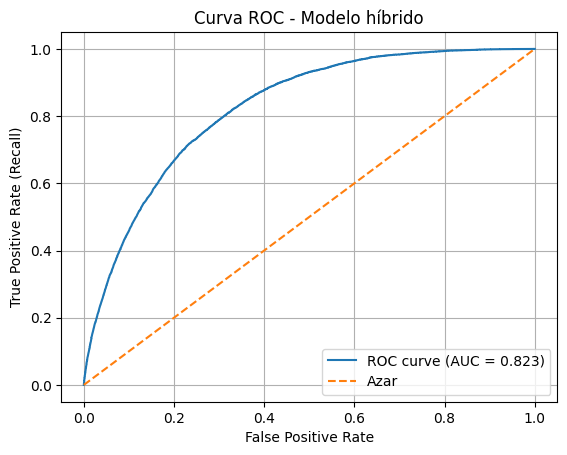

In [19]:
# Probabilidades de la clase positiva (ajusta el índice si tu clase positiva no es 1)
y_proba = pipeline_hybrid.predict_proba(X_test_)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_, y_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC - Modelo híbrido")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

La curva ROC del modelo híbrido muestra una mejora clara frente al azar, alcanzando un AUC de **0.823**, lo que indica una capacidad sólida para discriminar entre individuos con y sin diabetes. La curva se eleva de forma pronunciada en los primeros tramos, reflejando que el modelo logra altos niveles de **recall** incluso con incrementos moderados en la tasa de falsos positivos. Este comportamiento es característico de modelos que priorizan la detección de la clase minoritaria, coherente con el enfoque cost-sensitive y el uso combinado de dos algoritmos balanceados. En conjunto, la curva ROC confirma que el ensamble híbrido mantiene una buena capacidad discriminativa en un escenario fuertemente desbalanceado.


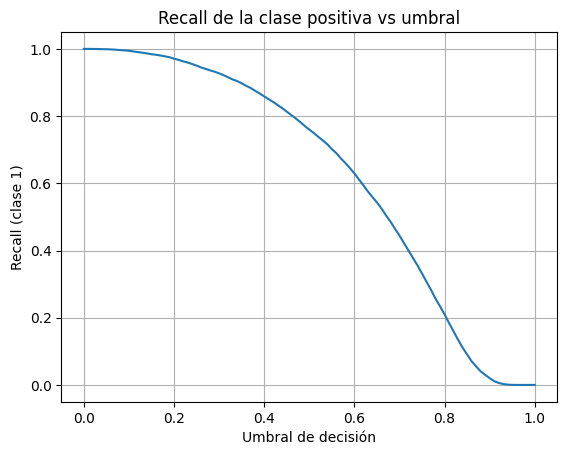

In [20]:
thresholds_recall = np.linspace(0.0, 1.0, 101)
recalls = []

for thr in thresholds_recall:
    y_pred_thr = (y_proba >= thr).astype(int)
    rec = recall_score(y_test_, y_pred_thr, pos_label=1)
    recalls.append(rec)

plt.figure()
plt.plot(thresholds_recall, recalls)
plt.xlabel("Umbral de decisión")
plt.ylabel("Recall (clase 1)")
plt.title("Recall de la clase positiva vs umbral")
plt.grid(True)
plt.show()


La gráfica de **recall de la clase positiva en función del umbral** muestra cómo varía la capacidad del modelo híbrido para identificar correctamente los casos de diabetes a medida que se endurece el criterio de decisión. Con umbrales bajos (entre 0.0 y 0.2), el modelo alcanza un recall cercano al 100 %, lo cual es esperable porque prácticamente cualquier probabilidad es clasificada como positiva. A medida que el umbral aumenta, el recall disminuye de forma progresiva y estable, reflejando la pérdida de sensibilidad a cambio de decisiones más conservadoras. La caída se vuelve más pronunciada a partir de 0.6, hasta casi llegar a cero cuando el umbral supera 0.9. Esta curva confirma que el modelo permite ajustar el balance entre sensibilidad y precisión, lo cual es especialmente útil en problemas médicos donde la detección temprana (alto recall) es prioritaria.


## **Referencias**

**[1] Zhang, Y. (2019).**  
*CMBoost: Cost-sensitive margin-based boosting algorithm.*  
IOP Conference Series: Materials Science and Engineering, 533(1), 012047.  
[doi:10.1088/1757-899X/533/1/012047](https://doi.org/10.1088/1757-899X/533/1/012047)

**[2] Pes, L., & Lai, C. (2021).**  
*Cost-sensitive learning strategies for high-dimensional imbalanced data.*  
PeerJ Computer Science, 7:e832.  
https://peerj.com/articles/cs-832/

**[3] Kadkhodaei, M., Minaei-Bidgoli, B., & develops others (2021).**  
*Big data classification using heterogeneous ensemble of deep learning and machine learning models.*  
Expert Systems with Applications, 183, 115351.  
https://doi.org/10.1016/j.eswa.2021.115351